In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
df  = pd.read_csv('SpotifyFeatures.csv')
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [3]:
df.isnull().sum()

genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

In [4]:
df.drop(['artist_name','track_name','track_id', 'genre'], axis=1, inplace=True)

In [5]:
df = pd.get_dummies(df, columns=['key','mode','time_signature'])

In [6]:
x = df

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

K-Means

In [8]:
inertia = []

for k in range(1,6):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans .fit(X_scaled)
  inertia.append(kmeans.inertia_)

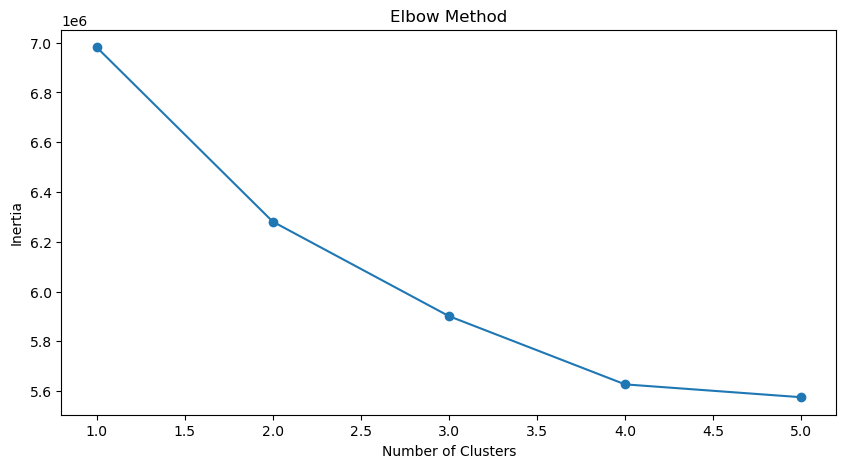

In [9]:
plt.figure(figsize=(10,5))
plt.plot(range(1,6), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [10]:
y_p = kmeans.predict(X_scaled)

In [11]:
df['cluster']= y_p
df

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,...,key_G,key_G#,mode_Major,mode_Minor,time_signature_0/4,time_signature_1/4,time_signature_3/4,time_signature_4/4,time_signature_5/4,cluster
0,0,0.61100,0.389,99373,0.910,0.000000,0.3460,-1.828,0.0525,166.969,...,False,False,True,False,False,False,False,True,False,4
1,1,0.24600,0.590,137373,0.737,0.000000,0.1510,-5.559,0.0868,174.003,...,False,False,False,True,False,False,False,True,False,0
2,3,0.95200,0.663,170267,0.131,0.000000,0.1030,-13.879,0.0362,99.488,...,False,False,False,True,False,False,False,False,True,3
3,0,0.70300,0.240,152427,0.326,0.000000,0.0985,-12.178,0.0395,171.758,...,False,False,True,False,False,False,False,True,False,1
4,4,0.95000,0.331,82625,0.225,0.123000,0.2020,-21.150,0.0456,140.576,...,False,False,True,False,False,False,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232720,39,0.00384,0.687,326240,0.714,0.544000,0.0845,-10.626,0.0316,115.542,...,False,False,True,False,False,False,False,True,False,4
232721,38,0.03290,0.785,282447,0.683,0.000880,0.2370,-6.944,0.0337,113.830,...,False,False,False,True,False,False,False,True,False,4
232722,47,0.90100,0.517,166960,0.419,0.000000,0.0945,-8.282,0.1480,84.135,...,False,False,True,False,False,False,False,True,False,4
232723,44,0.26200,0.745,222442,0.704,0.000000,0.3330,-7.137,0.1460,100.031,...,False,False,True,False,False,False,False,True,False,4


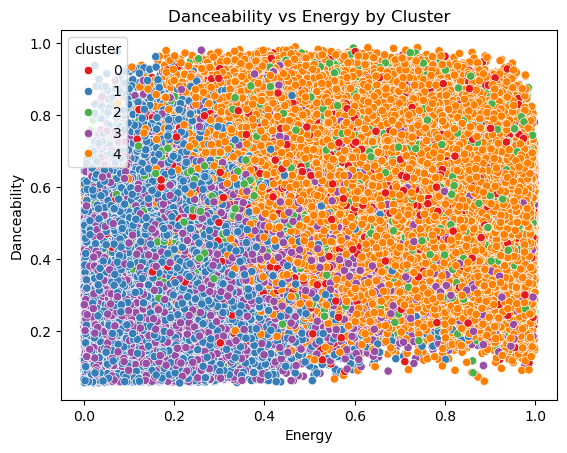

In [12]:
sns.scatterplot(x='energy', y='danceability', hue='cluster', data=df, palette='Set1')

plt.xlabel('Energy')
plt.ylabel('Danceability')
plt.title('Danceability vs Energy by Cluster')

plt.show()

DBSCAN

In [ ]:
dbscan= DBSCAN(eps=20, min_samples=2)

dbscan.fit(X_scaled)

y_p = dbscan.fit_predict(X_scaled)

In [ ]:
df['cluster']= y_p
df['cluster'].value_counts()

cluster
-1        61530
 1        12195
 19       10784
 7         9856
 29        8240
          ...  
 19194        2
 19195        2
 19196        2
 19224        2
 11           2
Name: count, Length: 19243, dtype: int64

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(data=df,x='energy',y='danceability',hue=y_p,s=60,palette='Set1')
plt.title('DBSCAN Clustering')
plt.xlabel('Energy')
plt.ylabel('Danceability')

plt.show()

c:\Users\Hend\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


In [ ]:
score = silhouette_score(x_scaled,y_p)
score